In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "/content/drive/MyDrive/Data_Mining/exoplanets.csv"
)

In [3]:
df.head()

,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,10811496,K00753.01,NaN,CANDIDATE,CANDIDATE,0.000,0,0,0,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


In [4]:
df.columns

Index(['kepid', 'kepoi_name', 'kepler_name', 'koi_disposition',
       'koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss',
       'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_period_err1',
       'koi_period_err2', 'koi_time0bk', 'koi_time0bk_err1',
       'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2',
       'koi_duration', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth',
       'koi_depth_err1', 'koi_depth_err2', 'koi_prad', 'koi_prad_err1',
       'koi_prad_err2', 'koi_teq', 'koi_teq_err1', 'koi_teq_err2', 'koi_insol',
       'koi_insol_err1', 'koi_insol_err2', 'koi_model_snr', 'koi_tce_plnt_num',
       'koi_tce_delivname', 'koi_steff', 'koi_steff_err1', 'koi_steff_err2',
       'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad',
       'koi_srad_err1', 'koi_srad_err2', 'ra', 'dec', 'koi_kepmag'],
      dtype='object')

In [5]:
df.shape

(9564, 49)

In [6]:
df.isnull().sum()

,0
kepid,0
kepoi_name,0
kepler_name,7205
koi_disposition,0
koi_pdisposition,0
koi_score,1510
koi_fpflag_nt,0
koi_fpflag_ss,0
koi_fpflag_co,0
koi_fpflag_ec,0


In [7]:
# Basic ML tools
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

In [8]:
# CREATE HABITABILITY LABEL (0/1/2)


R = df['koi_prad']      # Planet radius
Teq = df['koi_teq']     # Equilibrium temperature
Insol = df['koi_insol'] # Insolation
Teff = df['koi_steff']  # Stellar effective temperature

# Start with all as class 0 (not habitable)
habitability = np.zeros(len(df), dtype=int)

strict_mask = (
    (R.between(0.8, 1.8)) &
    (Teq.between(260, 320)) &
    (Insol.between(0.5, 1.5)) &
    (Teff.between(2600, 7200))
)


partial_mask = (
    (~strict_mask) &                # not already strict habitable
    (R.between(0.5, 2.5)) &         # broader range of rocky / super-Earth sizes
    (Teq.between(180, 350)) &       # wider temperature range
    (Insol.between(0.2, 2.0))       # wider insolation range
)

# Assign labels: 2 = habitable, 1 = partially, 0 = not
habitability[strict_mask] = 2
habitability[partial_mask] = 1

df['habitability_label'] = habitability


mask_false_pos = df['koi_disposition'].isin(['FALSE POSITIVE'])
df.loc[mask_false_pos, 'habitability_label'] = 0

# Inspect distribution of the new labels
print(df['habitability_label'].value_counts())


habitability_label
0    9366
1     186
2      12
Name: count, dtype: int64


In [9]:
df.shape

(9564, 50)

In [10]:
import pandas as pd
import numpy as np

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE


In [11]:
# 3-class label already created: 0,1,2
y3 = df['habitability_label']
y3.value_counts()

,count
habitability_label,
0,9366
1,186
2,12


In [12]:
# Drop IDs / leakage columns
id_cols = ['kepid', 'kepoi_name', 'kepler_name', 'koi_tce_delivname', 'ra', 'dec']
id_cols = [c for c in id_cols if c in df.columns]

X = df.drop(columns=id_cols + ['habitability_label'])

# Split into train/test ONCE, stratified on 3-class labels
X_train_raw, X_test_raw, y_train_3, y_test_3 = train_test_split(
    X, y3,
    test_size=0.2,
    random_state=42,
    stratify=y3
)

print("3-class train distribution:", Counter(y_train_3))

3-class train distribution: Counter({0: 7493, 1: 149, 2: 9})


In [13]:
# Separate numeric and categorical columns
num_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# Fit imputers/encoders on TRAIN ONLY
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Impute numeric
X_train_num = num_imputer.fit_transform(X_train_raw[num_cols])
X_test_num  = num_imputer.transform(X_test_raw[num_cols])

# Scale numeric for stability (optional for trees but ok)
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_num)
X_test_num  = scaler.transform(X_test_num)

# Impute + one-hot encode categorical
if len(cat_cols) > 0:
    X_train_cat_raw = cat_imputer.fit_transform(X_train_raw[cat_cols])
    X_test_cat_raw  = cat_imputer.transform(X_test_raw[cat_cols])

    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_train_cat = ohe.fit_transform(X_train_cat_raw)
    X_test_cat  = ohe.transform(X_test_cat_raw)

    # Concatenate numeric + categorical
    X_train = np.hstack([X_train_num, X_train_cat])
    X_test  = np.hstack([X_test_num,  X_test_cat])
else:
    X_train = X_train_num
    X_test  = X_test_num

print("Final train matrix shape:", X_train.shape)


Final train matrix shape: (7651, 44)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['koi_teq_err1' 'koi_teq_err2']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['koi_teq_err1' 'koi_teq_err2']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [14]:
# Stage 1 – binary model (0 vs 1+2)

# Binary labels: 0 = non-habitable, 1 = candidate (1 or 2)
y_train_bin = (y_train_3 > 0).astype(int)
y_test_bin  = (y_test_3 > 0).astype(int)

print("Stage 1 train binary distribution:", Counter(y_train_bin))

# Optional: apply SMOTE to balance binary classes
smote1 = SMOTE(sampling_strategy=1.0, random_state=42)
X_train_bin_sm, y_train_bin_sm = smote1.fit_resample(X_train, y_train_bin)

print("After SMOTE (Stage 1):", Counter(y_train_bin_sm))

# Train Random Forest for Stage 1
rf1 = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf1.fit(X_train_bin_sm, y_train_bin_sm)

# Evaluate Stage 1
y_pred_bin = rf1.predict(X_test)

print("=== Stage 1: 0 vs (1+2) ===")
print(classification_report(y_test_bin, y_pred_bin))
print(confusion_matrix(y_test_bin, y_pred_bin))


Stage 1 train binary distribution: Counter({0: 7493, 1: 158})
After SMOTE (Stage 1): Counter({0: 7493, 1: 7493})
=== Stage 1: 0 vs (1+2) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1873
           1       0.97      0.95      0.96        40

    accuracy                           1.00      1913
   macro avg       0.99      0.97      0.98      1913
weighted avg       1.00      1.00      1.00      1913

[[1872    1]
 [   2   38]]


In [15]:
# Stage 2 – classify 1 vs 2 on candidates

# Training data for Stage 2: only TRAIN rows with true labels 1 or 2
cand_train_mask = y_train_3 > 0
X_train_cand = X_train[cand_train_mask]
y_train_12   = y_train_3[cand_train_mask]   # values 1 or 2

print("Stage 2 train 1/2 distribution:", Counter(y_train_12))

# Test data for Stage 2:
# Use TEST rows that Stage 1 predicted as candidate (1),
# then evaluate only on those whose TRUE label is 1 or 2.
cand_test_mask_pred = (y_pred_bin == 1)
X_test_cand_all = X_test[cand_test_mask_pred]
y_test_3_cand_all = y_test_3[cand_test_mask_pred]

print("Stage 2 candidate TEST labels (may include some 0s):")
print(Counter(y_test_3_cand_all))

# For pure evaluation of Stage 2, filter to true 1 or 2
mask_true_12 = y_test_3_cand_all > 0
X_test_cand = X_test_cand_all[mask_true_12]
y_test_12   = y_test_3_cand_all[mask_true_12]

print("Stage 2 eval set distribution:", Counter(y_test_12))


Stage 2 train 1/2 distribution: Counter({1: 149, 2: 9})
Stage 2 candidate TEST labels (may include some 0s):
Counter({1: 36, 2: 2, 0: 1})
Stage 2 eval set distribution: Counter({1: 36, 2: 2})


In [16]:
# Convert labels to 0/1 for SMOTE + RF
# map: 1 -> 0, 2 -> 1
y_train_01 = (y_train_12 == 2).astype(int)   # 0 = class 1, 1 = class 2
y_test_01  = (y_test_12 == 2).astype(int)

print("Stage 2 train 0/1 distribution:", Counter(y_train_01))

# SMOTE to balance 1 vs 2
smote2 = SMOTE(sampling_strategy='auto', k_neighbors=3, random_state=42)
X_train_2_sm, y_train_01_sm = smote2.fit_resample(X_train_cand, y_train_01)

print("After SMOTE (Stage 2):", Counter(y_train_01_sm))

rf2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42
)

rf2.fit(X_train_2_sm, y_train_01_sm)

# Evaluate Stage 2 on candidate test subset
y_pred_01 = rf2.predict(X_test_cand)

print("=== Stage 2: 1 vs 2 (only candidates) ===")
print(classification_report(y_test_01, y_pred_01))
print(confusion_matrix(y_test_01, y_pred_01))


Stage 2 train 0/1 distribution: Counter({0: 149, 1: 9})
After SMOTE (Stage 2): Counter({0: 149, 1: 149})
=== Stage 2: 1 vs 2 (only candidates) ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.67      1.00      0.80         2

    accuracy                           0.97        38
   macro avg       0.83      0.99      0.89        38
weighted avg       0.98      0.97      0.98        38

[[35  1]
 [ 0  2]]


In [17]:
# Start from Stage 1 predictions on the full TEST set
y_pred_final = np.zeros_like(y_test_3.values)

# Non-candidates -> class 0
non_cand_idx = (y_pred_bin == 0)
cand_idx     = (y_pred_bin == 1)

y_pred_final[non_cand_idx] = 0

# For every candidate (Stage 1 = 1), use Stage 2 to decide 1 vs 2
X_test_candidates_all = X_test[cand_idx]
y_pred_01_all = rf2.predict(X_test_candidates_all)

# map back: 0 -> label 1, 1 -> label 2
y_pred_12_all = np.where(y_pred_01_all == 1, 2, 1)

y_pred_final[cand_idx] = y_pred_12_all

print("=== Final 3-class hierarchical result ===")
print(classification_report(y_test_3, y_pred_final))
print(confusion_matrix(y_test_3, y_pred_final))


=== Final 3-class hierarchical result ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1873
           1       0.97      0.95      0.96        37
           2       0.67      0.67      0.67         3

    accuracy                           1.00      1913
   macro avg       0.88      0.87      0.87      1913
weighted avg       1.00      1.00      1.00      1913

[[1872    1    0]
 [   1   35    1]
 [   1    0    2]]


In [18]:
from xgboost import XGBClassifier  # pip install xgboost
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix

In [19]:
# Stage 1: XGBoost, binary task

# Binary labels: 0 = non-habitable, 1 = candidate (1 or 2)
y_train_bin = (y_train_3 > 0).astype(int)
y_test_bin  = (y_test_3 > 0).astype(int)

print("Stage 1 train binary distribution:", Counter(y_train_bin))

# SMOTE to balance 0 and 1
smote1 = SMOTE(sampling_strategy=1.0, random_state=42)
X_train_bin_sm, y_train_bin_sm = smote1.fit_resample(X_train, y_train_bin)
print("After SMOTE (Stage 1):", Counter(y_train_bin_sm))

# XGBoost model for binary classification
xgb1 = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

xgb1.fit(X_train_bin_sm, y_train_bin_sm)

# Evaluate Stage 1
y_pred_bin = (xgb1.predict_proba(X_test)[:, 1] >= 0.5).astype(int)

print("=== Stage 1 XGBoost: 0 vs (1+2) ===")
print(classification_report(y_test_bin, y_pred_bin))
print(confusion_matrix(y_test_bin, y_pred_bin))


Stage 1 train binary distribution: Counter({0: 7493, 1: 158})
After SMOTE (Stage 1): Counter({0: 7493, 1: 7493})
=== Stage 1 XGBoost: 0 vs (1+2) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1873
           1       0.97      0.95      0.96        40

    accuracy                           1.00      1913
   macro avg       0.99      0.97      0.98      1913
weighted avg       1.00      1.00      1.00      1913

[[1872    1]
 [   2   38]]


In [20]:
# Build train/test sets for Stage 2 (1 vs 2)

# TRAIN: only true 1 or 2 from train set
cand_train_mask = y_train_3 > 0
X_train_cand = X_train[cand_train_mask]
y_train_12   = y_train_3[cand_train_mask]    # 1 or 2

# map labels: 1 -> 0, 2 -> 1
y_train_01 = (y_train_12 == 2).astype(int)
print("Stage 2 train 0/1 distribution:", Counter(y_train_01))

# TEST: use test rows predicted as candidate by Stage 1
cand_test_mask_pred = (y_pred_bin == 1)
X_test_cand_all = X_test[cand_test_mask_pred]
y_test_3_cand_all = y_test_3[cand_test_mask_pred]

# For clean Stage 2 evaluation, keep only true 1 or 2
mask_true_12 = (y_test_3_cand_all > 0)
X_test_cand = X_test_cand_all[mask_true_12]
y_test_12   = y_test_3_cand_all[mask_true_12]
y_test_01   = (y_test_12 == 2).astype(int)

print("Stage 2 eval 0/1 distribution:", Counter(y_test_01))


Stage 2 train 0/1 distribution: Counter({0: 149, 1: 9})
Stage 2 eval 0/1 distribution: Counter({0: 35, 1: 3})


In [21]:
# SMOTE to balance 1 vs 2 in Stage 2
smote2 = SMOTE(sampling_strategy='auto', k_neighbors=3, random_state=42)
X_train_2_sm, y_train_01_sm = smote2.fit_resample(X_train_cand, y_train_01)
print("After SMOTE (Stage 2):", Counter(y_train_01_sm))

xgb2 = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

xgb2.fit(X_train_2_sm, y_train_01_sm)

# Evaluate Stage 2 on 1 vs 2 subset
y_pred_01 = (xgb2.predict_proba(X_test_cand)[:, 1] >= 0.5).astype(int)

print("=== Stage 2 XGBoost: 1 vs 2 (candidates) ===")
print(classification_report(y_test_01, y_pred_01))
print(confusion_matrix(y_test_01, y_pred_01))

After SMOTE (Stage 2): Counter({0: 149, 1: 149})
=== Stage 2 XGBoost: 1 vs 2 (candidates) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00         3

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

[[35  0]
 [ 0  3]]


In [22]:
# Final 3-class prediction via two XGBoost stages

y_pred_final = np.zeros_like(y_test_3.values)

# Stage 1 result decides 0 vs candidate
non_cand_idx = (y_pred_bin == 0)
cand_idx     = (y_pred_bin == 1)

y_pred_final[non_cand_idx] = 0

# For all candidates, Stage 2 decides 1 vs 2
X_test_cand_all = X_test[cand_idx]
y_pred_01_all   = (xgb2.predict_proba(X_test_cand_all)[:, 1] >= 0.5).astype(int)

# map 0 -> label 1, 1 -> label 2
y_pred_12_all = np.where(y_pred_01_all == 1, 2, 1)
y_pred_final[cand_idx] = y_pred_12_all

print("=== Final 3-class hierarchical XGBoost result ===")
print(classification_report(y_test_3, y_pred_final))
print(confusion_matrix(y_test_3, y_pred_final))


=== Final 3-class hierarchical XGBoost result ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1873
           1       0.97      0.95      0.96        37
           2       1.00      1.00      1.00         3

    accuracy                           1.00      1913
   macro avg       0.99      0.98      0.99      1913
weighted avg       1.00      1.00      1.00      1913

[[1872    1    0]
 [   2   35    0]
 [   0    0    3]]


In [23]:
# 0. Build full raw feature frame (no label, no IDs)
df_all = df.copy()
X_all_raw = df_all.drop(columns=id_cols + ['habitability_label'])

# Use the SAME num_imputer, scaler, cat_imputer, ohe that you already fitted
X_all_num = num_imputer.transform(X_all_raw[num_cols])
X_all_num = scaler.transform(X_all_num)

if len(cat_cols) > 0:
    X_all_cat_raw = cat_imputer.transform(X_all_raw[cat_cols])
    X_all_cat = ohe.transform(X_all_cat_raw)
    X_all = np.hstack([X_all_num, X_all_cat])
else:
    X_all = X_all_num

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['koi_teq_err1' 'koi_teq_err2']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [24]:
# 1. Stage 1 probabilities on ALL rows
prob_cand = xgb1.predict_proba(X_all)[:, 1]

candidate_mask = (prob_cand >= 0.5)

# 2. Stage 2 probabilities only for candidates
X_all_cand = X_all[candidate_mask]
prob_class2_stage2 = xgb2.predict_proba(X_all_cand)[:, 1]

# 3. Combined habitability score
hab_score = prob_cand[candidate_mask] * prob_class2_stage2

# 4. Attach back and get top 10
df_candidates = df_all[candidate_mask].copy()
df_candidates['habitable_score'] = hab_score

top10 = df_candidates.sort_values('habitable_score', ascending=False).head(10)

cols_to_show = ['kepid', 'kepoi_name', 'kepler_name',
                'habitability_label', 'habitable_score',
                'koi_prad', 'koi_teq', 'koi_insol', 'koi_period', 'koi_steff']
cols_to_show = [c for c in cols_to_show if c in top10.columns]

print(top10[cols_to_show])


         kepid kepoi_name     kepler_name  habitability_label  \
7964   9480398  K07179.01             NaN                   2   
9220  10331279  K08000.01             NaN                   2   
6938   8294683  K05499.01             NaN                   2   
6674  10552263  K05806.01             NaN                   2   
6143   5439000  K05165.01             NaN                   2   
9372   5956171  K08259.01             NaN                   2   
3474   9002278  K00701.03     Kepler-62 e                   2   
5207   8424002  K03497.01   Kepler-1512 b                   2   
6223   2437653  K04940.01             NaN                   2   
3272   8845205  K00463.01  Kepler-560 B b                   2   

      habitable_score  koi_prad  koi_teq  koi_insol  koi_period  koi_steff  
7964         0.996387      1.18    272.0       1.29  407.146560     5845.0  
9220         0.993975      1.70    267.0       1.20  225.488050     5663.0  
6938         0.993488      1.19    279.0       1.43  

#VISUALISATION

/tmp/ipykernel_5694/1562578622.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts.values, palette="Blues_d")


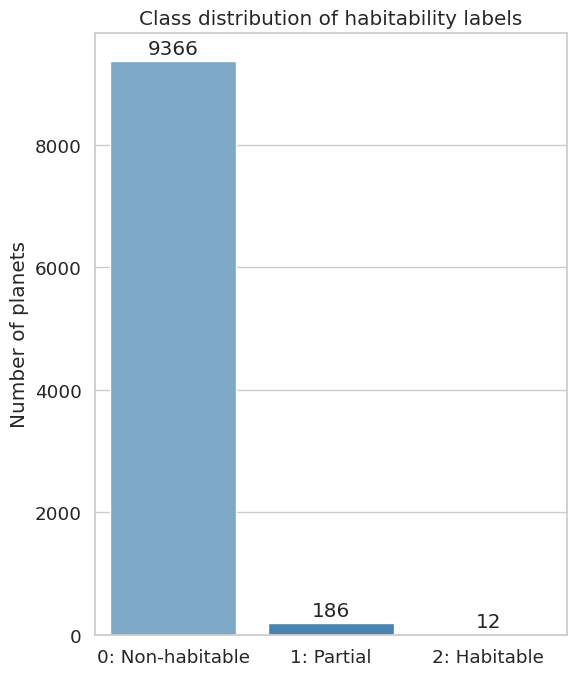

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)

counts = df['habitability_label'].value_counts().sort_index()
labels = ['0: Non-habitable', '1: Partial', '2: Habitable']

plt.figure(figsize=(6,7))
sns.barplot(x=labels, y=counts.values, palette="Blues_d")
plt.ylabel("Number of planets")
plt.title("Class distribution of habitability labels")
for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()


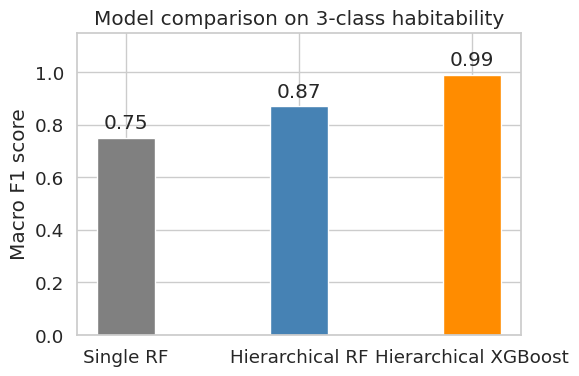

In [49]:
import numpy as np
import matplotlib.pyplot as plt

models = ['Single RF',
          'Hierarchical RF',
          'Hierarchical XGBoost']
macro_f1 = [0.75, 0.87, 0.99]

# Create custom x positions with more spacing
x = np.arange(len(models)) * 1.5   # increase spacing (default is 1.0)

plt.figure(figsize=(6,4))
bars = plt.bar(x, macro_f1, width=0.5, color=['gray', 'steelblue', 'darkorange'])

plt.ylabel("Macro F1 score")
plt.ylim(0, 1.15)
plt.title("Model comparison on 3-class habitability")

# Set custom x-ticks
plt.xticks(x, models)

for b, s in zip(bars, macro_f1):
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
             f"{s:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

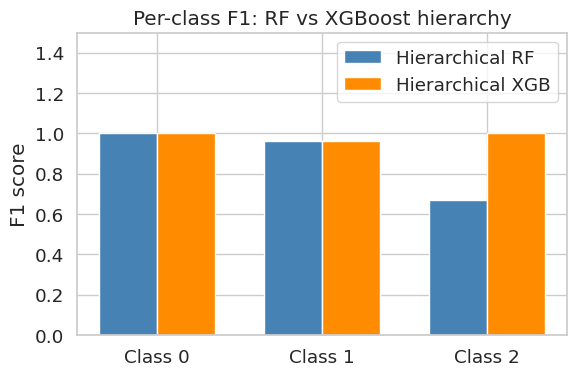

In [37]:
import numpy as np
import matplotlib.pyplot as plt

classes = ['Class 0', 'Class 1', 'Class 2']

# Fill with your measured F1s per class
f1_rf =  [1.00, 0.96, 0.67]   # hierarchical RF
f1_xgb = [1.00, 0.96, 1.00]   # hierarchical XGBoost

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar(x - width/2, f1_rf,  width, label='Hierarchical RF',   color='steelblue')
plt.bar(x + width/2, f1_xgb, width, label='Hierarchical XGB', color='darkorange')

plt.xticks(x, classes)
plt.ylabel("F1 score")
plt.ylim(0, 1.5)
plt.title("Per-class F1: RF vs XGBoost hierarchy")
plt.legend()
plt.tight_layout()
plt.show()


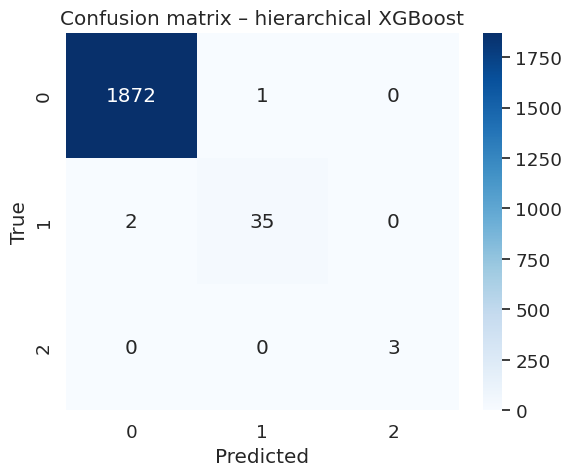

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# y_test_3, y_pred_final from hierarchical XGBoost
cm = confusion_matrix(y_test_3, y_pred_final, labels=[0,1,2])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0','1','2'],
            yticklabels=['0','1','2'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix – hierarchical XGBoost")
plt.tight_layout()
plt.show()
